In [1]:
# general python modules for scientific analysis
import sys, pathlib, os, itertools
import numpy as np
import pandas as pd
import matplotlib.pylab as plt

# add the physion path:
sys.path.append('../../../physion/src')
from physion.analysis.read_NWB import Data, scan_folder_for_NWBfiles
from physion.analysis.process_NWB import EpisodeData
from physion.dataviz.raw import plot as plot_raw
from physion.dataviz.episodes.trial_average import plot as plot_trial_average
from physion.utils import plot_tools as pt
import scipy.stats as stats_func

import seaborn as sns

In [2]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs_test')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\my_experiments\All_NWBs_test" [...]
 -> found n=17 datafiles (in 10.8s) 


In [3]:
def get_stats(all_diffs_act, all_diffs_rest):
    
    t_stats, p_val = stats_func.ttest_ind(all_diffs_act, all_diffs_rest)
    significance = 'ns'                  
    if p_val==np.nan or p_val>0.05:
        significance = 'ns'  # Default is "not significant"
    elif p_val < 0.001:
        significance = '***'
    elif p_val < 0.01:
        significance = '**'
    elif p_val < 0.05:
        significance = '*'

    return t_stats, p_val, significance

## Example for 1 file

In [4]:
index = 8
filename = SESSIONS['files'][index]
data = Data(filename,
            verbose=False)
data.build_dFoF(verbose=False)

episodes = EpisodeData(data, 
                       quantities=['dFoF', 'Pupil', 'Running-Speed'],
                       protocol_name=data.protocols,
                       prestim_duration=0,
                       verbose=False)

Difference across episodes for a specific roi

Text(0.5, 1.0, 'Roi #10')

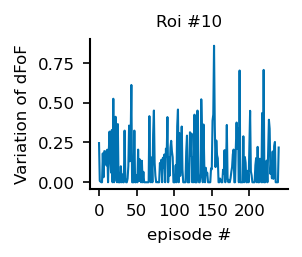

In [13]:
roi = 10
diffs = []
for i in range(len(episodes.dFoF[:,roi,:])):
    ini_val = episodes.dFoF[i,roi,1000]
    max_val = np.max(episodes.dFoF[i,roi,[1000,3000]])
    diff = max_val - ini_val
    diffs.append(diff)

plt.plot(diffs)
plt.xticks(np.arange(0,250,50)) 
plt.xlabel("episode #") 
plt.ylabel("Variation of dFoF")
plt.title(f"Roi #{roi}")

Difference across roi (mean of all episodes)

46


Text(0, 0.5, 'Variation of dFoF')

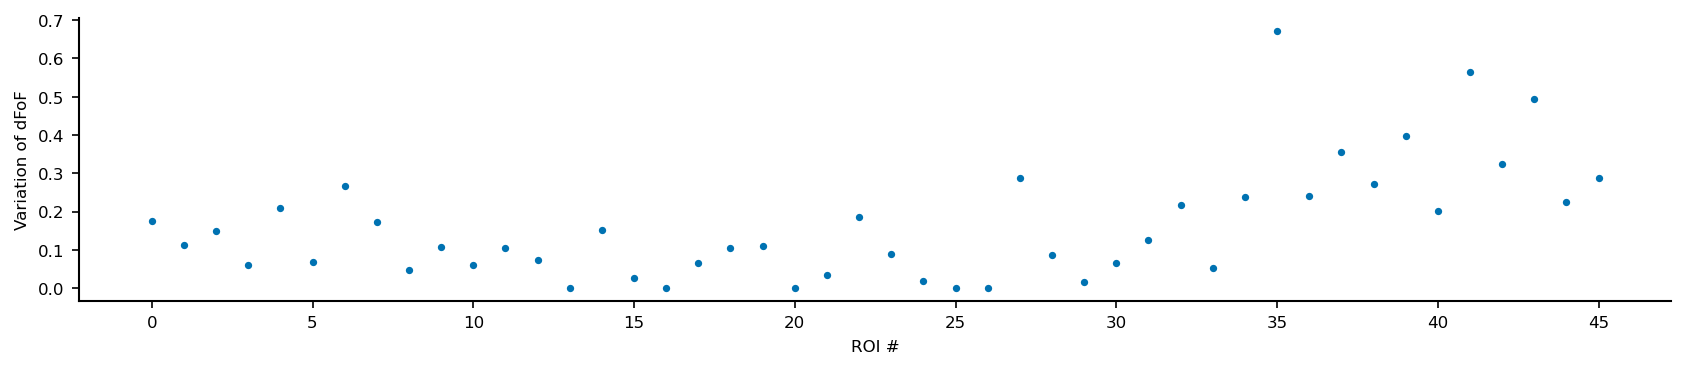

In [14]:
diffs = []
for i in range(len(episodes.dFoF[:,:,:].mean(axis=0))):
    ini_val = episodes.dFoF[:,i,1000].mean(axis=0)
    max_val = np.max(episodes.dFoF[:,i,[1000,3000]].mean(axis=0))
    diff = max_val - ini_val
    diffs.append(diff)

print(len(diffs))

fig, ax = pt.figure(figsize=(3.5, 3))
plt.scatter(np.arange(0, len(diffs),1), diffs)
plt.xticks(np.arange(0,len(diffs),5)) 
plt.xlabel("ROI #") 
plt.ylabel("Variation of dFoF")


## Differentiate active and resting state

In [28]:
def compute_high_movement_cond(episodes, running_speed_threshold):
    if running_speed_threshold is not None:
        HMcond = (episodes.running_speed > running_speed_threshold)   
    return HMcond

In [29]:
# HMcond: high movement condition
HMcond = compute_high_movement_cond(episodes, running_speed_threshold=0.1)
HMcond_ = HMcond[:, np.arange(1000, 3000)]  # Extracts values between 1000 and 2999
final_cond = []
for i in range(len(HMcond_)):
    if np.sum(HMcond[i])>1500:
        final_cond.append(True)
    else: 
        final_cond.append(False)

a 3998
3998
2000
240


episodes active  :  23
episodes resting :  204
average for active episodes  : 0.87
average for resting episodes : 0.73


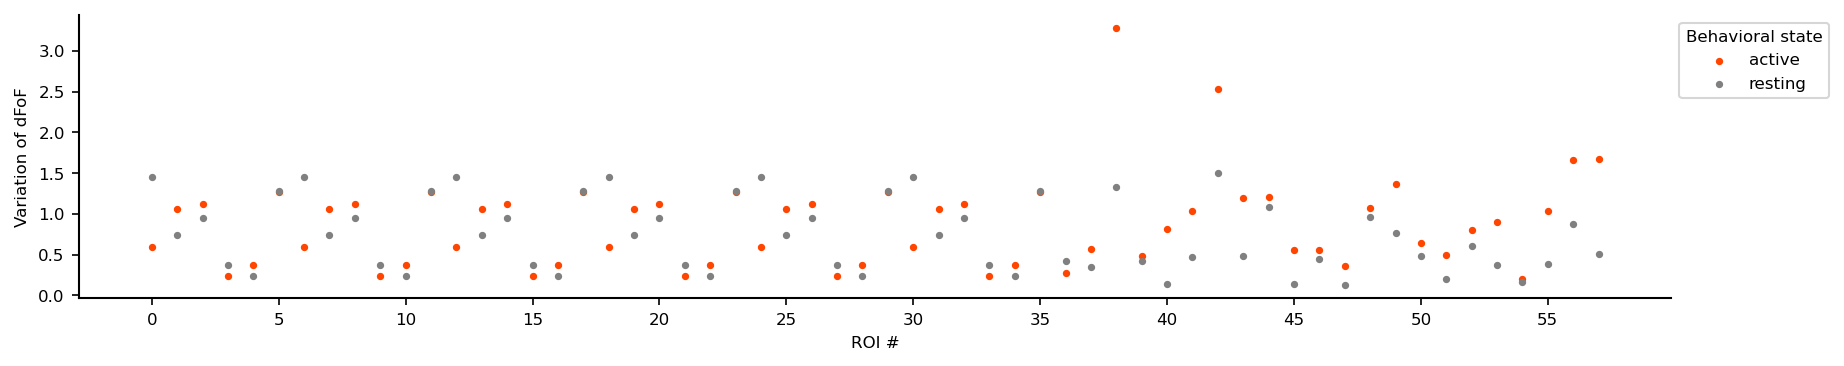

In [8]:


fig, ax = pt.figure(figsize=(3.5, 3))

#active
episodes_act = episodes.dFoF[final_cond]
diffs_act = []
for i in range(len(episodes_act[:,:,:].mean(axis=0))):
    ini_val = episodes_act[:,i,1000].mean(axis=0)
    max_val = np.max(episodes_act[:,i,[1000,3000]].mean(axis=0))
    diff = max_val - ini_val
    diffs_act.append(diff)

plt.scatter(np.arange(0, len(diffs_act),1), diffs_act, color='orangered', label = 'active')


#rest
final_cond = np.array(final_cond) 
episodes_rest = episodes.dFoF[~final_cond]

diffs_rest = []
n_roi = len(episodes_rest[:,:,:].mean(axis=0))

for roi in range(n_roi):
    ini_val = episodes_rest[:,roi,1000].mean(axis=0)
    max_val = np.max(episodes_rest[:,roi,[1000,3000]].mean(axis=0))
    diff = max_val - ini_val
    diffs_rest.append(diff)
    

plt.scatter(np.arange(0, len(diffs_rest),1), diffs_rest, color='grey', label="resting")
#plt.set_xlabel("ROI #")
plt.xlabel("ROI #") 
plt.ylabel("Variation of dFoF")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), title = "Behavioral state")
plt.xticks(np.arange(0,len(diffs_rest),5))  

print("episodes active  : ", len(episodes_act))
print("episodes resting : ", len(episodes_rest))
print(f"average for active episodes  : {np.mean(diffs_act):.2f}" )
print(f"average for resting episodes : {np.mean(diffs_rest):.2f}")


For each ROI, the variation of dFoF was plotted diving active and resting episodes (active were averaged together and resting were averaged together). Active episodes seem to be correlated to a bigger variation of dFoF.

## ALL files analysis

In [9]:
all_diffs_act = []
all_diffs_rest = []

datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs_test')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]


for index in range(len(SESSIONS['files'])):
    filename = SESSIONS['files'][index]
    data = Data(filename,
                verbose=False)
    data.build_dFoF(verbose=False)
    
    episodes = EpisodeData(data, 
                       quantities=['dFoF', 'Pupil', 'Running-Speed'],
                       protocol_name=data.protocols,
                       prestim_duration=0,
                       verbose=False)
    


    # HMcond: high movement condition
    HMcond = compute_high_movement_cond(episodes, running_speed_threshold=0.1)
    HMcond_ = HMcond[:, np.arange(1000, 3000)]  # Extracts values between 1000 and 2999
    final_cond = []
    for i in range(len(HMcond_)):
        if np.sum(HMcond[i])>1500:
            final_cond.append(True)
        else: 
            final_cond.append(False)
    
    
    
    
    #active
    episodes_act = episodes.dFoF[final_cond]
    diffs_act = []
    for i in range(len(episodes_act[:,:,:].mean(axis=0))):
        ini_val = episodes_act[:,i,1000].mean(axis=0)
        max_val = np.max(episodes_act[:,i,[1000,3000]].mean(axis=0))
        diff = max_val - ini_val
        diffs_act.append(diff)
        all_diffs_act.append(diff)
    
    #rest
    final_cond = np.array(final_cond) 
    episodes_rest = episodes.dFoF[~final_cond]
    
    diffs_rest = []
    n_roi = len(episodes_rest[:,:,:].mean(axis=0))
    
    for roi in range(n_roi):
        ini_val = episodes_rest[:,roi,1000].mean(axis=0)
        max_val = np.max(episodes_rest[:,roi,[1000,3000]].mean(axis=0))
        diff = max_val - ini_val
        diffs_rest.append(diff)
        all_diffs_rest.append(diff)
    

inspecting the folder "C:\Users\laura.gonzalez\DATA\In_Vivo_experiments\my_experiments\All_NWBs_test" [...]
 -> found n=17 datafiles (in 11.0s) 


([<matplotlib.axis.XTick at 0x1be11d0d130>,
 [Text(0, 0, '0'),
  Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50'),
  Text(55, 0, '55'),
  Text(60, 0, '60'),
  Text(65, 0, '65'),
  Text(70, 0, '70'),
  Text(75, 0, '75'),
  Text(80, 0, '80'),
  Text(85, 0, '85'),
  Text(90, 0, '90'),
  Text(95, 0, '95'),
  Text(100, 0, '100'),
  Text(105, 0, '105'),
  Text(110, 0, '110'),
  Text(115, 0, '115'),
  Text(120, 0, '120'),
  Text(125, 0, '125'),
  Text(130, 0, '130'),
  Text(135, 0, '135'),
  Text(140, 0, '140'),
  Text(145, 0, '145'),
  Text(150, 0, '150'),
  Text(155, 0, '155'),
  Text(160, 0, '160'),
  Text(165, 0, '165'),
  Text(170, 0, '170'),
  Text(175, 0, '175'),
  Text(180, 0, '180'),
  Text(185, 0, '185'),
  Text(190, 0, '190'),
  Text(195, 0, '195'),
  Text(200, 0, '200'),
  Text(205, 0, '205'),
  Text(210, 0, '210'),
  Text(215,

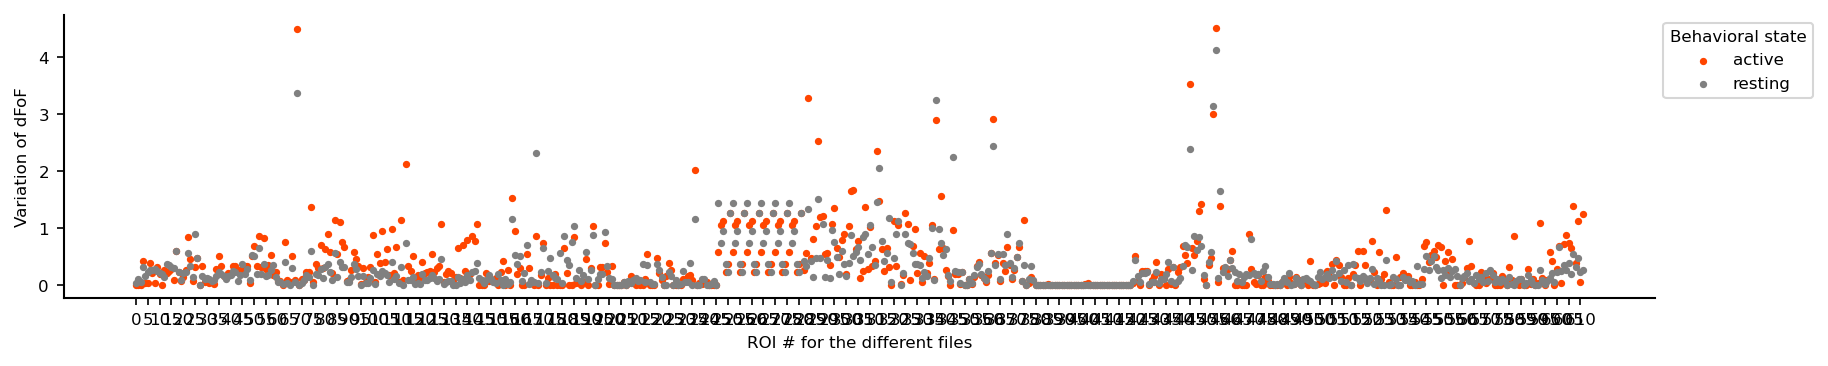

In [10]:
#plot
fig, ax = pt.figure(figsize=(3.5, 3))

plt.scatter(np.arange(0, len(all_diffs_act),1), all_diffs_act, color='orangered', label = 'active')
plt.scatter(np.arange(0, len(all_diffs_rest),1), all_diffs_rest, color='grey', label="resting")
#plt.set_xlabel("ROI #")
plt.xlabel("ROI # for the different files") 
plt.ylabel("Variation of dFoF")
plt.legend(loc="upper left", bbox_to_anchor=(1, 1), title = "Behavioral state")
plt.xticks(np.arange(0,len(all_diffs_rest),5))  

In [11]:
print("number of ROIs :", len(all_diffs_act))
print(f"active mean : {means[0]:.2f}, resting mean : {means[1]:.2f}")

###################################################
#barplot
fig, ax = pt.figure(figsize=(2, 4))

bar_width = 0.4
x = np.arange(2)  
means = [np.mean(all_diffs_act), np.mean(all_diffs_rest)]
plt.bar(x, means, width=bar_width, color=['orangered', 'grey'], edgecolor='black')
jitter_strength = 0.2  # Adjust for more/less jitter
x_act = np.full_like(all_diffs_act, x[0])
x_act_jitter = x_act + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_act))
x_rest = np.full_like(all_diffs_act, x[1])
x_rest_jitter = x_rest + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_rest))
plt.scatter(x_act_jitter, all_diffs_act, color='purple', zorder=4, label="Active", alpha=0.7)
plt.scatter(x_rest_jitter, all_diffs_rest, color='dimgrey', zorder=4, label="Resting", alpha=0.7)
plt.xticks(x, ['Active', 'Resting'])
plt.xlabel("Behavioral state")
plt.ylabel("Variation of dFoF")

t_stats, p_val, significance = get_stats(all_diffs_act, all_diffs_rest)
plt.plot([x[0], x[1]], [np.max([means[0], means[1]]) + 3] * 2, color='black', lw=0.8)  # Line above bars
plt.plot([x[0], x[0]], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
plt.plot([x[1], x[1]], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
plt.text(np.mean(x), np.max([means[0], means[1]]) + 3.1, f"{significance}    p = {p_val:.2}", ha='center', va='bottom', fontsize=8)

##################################################
#violin plot
fig, ax = pt.figure(figsize=(2, 4))

d = {'active': all_diffs_act, 'resting': all_diffs_rest}
df = pd.DataFrame(data=d)
df_melted = df.melt(var_name="Behavioral state", value_name="Variation of dFoF")
sns.violinplot(data=df_melted, x="Behavioral state", y="Variation of dFoF", inner="quart", palette={"active": "orangered", "resting": "grey"})

t_stats, p_val, significance = get_stats(all_diffs_act, all_diffs_rest)
print(f"t_stats : {t_stats:.2f}, p_value : {p_val:.2f}, significance : {significance}")
plt.plot([x[0]+0.1, x[1]-0.1], [np.max([means[0], means[1]]) + 3] * 2, color='black', lw=0.8)  # Line above bars
plt.plot([x[0]+0.1, x[0]+0.1], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
plt.plot([x[1]-0.1, x[1]-0.1], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
plt.text(np.mean(x), np.max([means[0], means[1]]) + 3.1, f"{significance}    p = {p_val:.3f}", ha='center', va='bottom', fontsize=8)


number of ROIs : 612


NameError: name 'means' is not defined

In [ ]:
datafolder = os.path.join(os.path.expanduser('~'), 'DATA', 'In_Vivo_experiments','my_experiments','All_NWBs_test')
SESSIONS = scan_folder_for_NWBfiles(datafolder)
SESSIONS['nwbfiles'] = [os.path.basename(f) for f in SESSIONS['files']]

variations_act = []
variations_rest = []

for index in range(len(SESSIONS['files'])):
    filename = SESSIONS['files'][index]
    data = Data(filename,
                verbose=False)
    data.build_dFoF(verbose=False)
    
    episodes = EpisodeData(data, 
                       quantities=['dFoF', 'Pupil', 'Running-Speed'],
                       protocol_name=data.protocols,
                       prestim_duration=0,
                       verbose=False)

    # HMcond: high movement condition
    HMcond = compute_high_movement_cond(episodes, running_speed_threshold=0.1)
    HMcond_ = HMcond[:, np.arange(1000, 3000)]  # Extracts values between 1000 and 2999
    final_cond = []
    for i in range(len(HMcond_)):
        if np.sum(HMcond[i])>1500:
            final_cond.append(True)
        else: 
            final_cond.append(False)
    
    
    #active
    episodes_act = episodes.dFoF[final_cond]
    diffs_act = []
    n_roi = len(episodes_act[:,:,:].mean(axis=0))
    for i in range(n_roi):
        ini_val = episodes_act[:,i,1000].mean(axis=0)
        max_val = np.max(episodes_act[:,i,[1000,3000]].mean(axis=0))
        diff = max_val - ini_val
        diffs_act.append(diff)
        
    variations_act.append(np.mean(diffs_act))    

    
    #rest
    final_cond = np.array(final_cond) 
    episodes_rest = episodes.dFoF[~final_cond]
    
    diffs_rest = []
    n_roi = len(episodes_rest[:,:,:].mean(axis=0))
    
    for roi in range(n_roi):
        ini_val = episodes_rest[:,roi,1000].mean(axis=0)
        max_val = np.max(episodes_rest[:,roi,[1000,3000]].mean(axis=0))
        diff = max_val - ini_val
        diffs_rest.append(diff)
    
    variations_rest.append(np.mean(diffs_rest))  


In [ ]:
cols = 2  # Number of columns per row
rows = 2  # Compute the required number of rows
#fig, AX = pt.figure(axes=(cols, rows), hspace=2, figsize=(2, 2))
fig, AX = plt.subplots(rows, cols, figsize=(6, 6))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

#############################################################################################################
#barplot all rois for all recordings
bar_width = 0.4
x = np.arange(2)  
means = [np.mean(all_diffs_act), np.mean(all_diffs_rest)]
AX[0][0].bar(x, means, width=bar_width, color=['orangered', 'grey'], edgecolor='black')
jitter_strength = 0.2  # Adjust for more/less jitter
x_act = np.full_like(all_diffs_act, x[0])
x_act_jitter = x_act + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_act))
x_rest = np.full_like(all_diffs_act, x[1])
x_rest_jitter = x_rest + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_rest))
AX[0][0].scatter(x_act_jitter, all_diffs_act, color='firebrick', zorder=4, label="Active", alpha=0.7)
AX[0][0].scatter(x_rest_jitter, all_diffs_rest, color='black', zorder=4, label="Resting", alpha=0.7)
AX[0][0].set_xticks(x, ['Active', 'Resting'])
AX[0][0].set_xlabel("Behavioral state")
AX[0][0].set_ylabel("Variation of dFoF")
AX[0][0].set_title(f"all ROIs for all recordings\n n = {len(all_diffs_act)}")

t_stats, p_val, significance = get_stats(all_diffs_act, all_diffs_rest)
AX[0][0].plot([x[0], x[1]], [np.max([means[0], means[1]]) + 3] * 2, color='black', lw=0.8)  # Line above bars
AX[0][0].plot([x[0], x[0]], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
AX[0][0].plot([x[1], x[1]], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
AX[0][0].text(np.mean(x), np.max([means[0], means[1]]) + 3.1, f"{significance}    p = {p_val:.2}", ha='center', va='bottom', fontsize=8)


# Calculate mean values for labels
means_ = df_melted.groupby("Behavioral state")["Variation of dFoF"].mean()

# Annotate each bar with its mean value
for i, mean in enumerate(means_):
    print(mean)
    AX[0][0].text(i, mean + 4, f'mean {mean:.3f}', ha='center', fontsize=6)


#############################################################################################################
#violing all rois for all recordings

d = {'active': all_diffs_act, 'resting': all_diffs_rest}
df = pd.DataFrame(data=d)
df_melted = df.melt(var_name="Behavioral state", value_name="Variation of dFoF")
sns.violinplot(data=df_melted, x="Behavioral state", y="Variation of dFoF", inner="quart", palette={"active": "orangered", "resting": "grey"}, ax=AX[0][1] )

t_stats, p_val, significance = get_stats(all_diffs_act, all_diffs_rest)
AX[0][1].plot([x[0]+0.1, x[1]-0.1], [np.max([means[0], means[1]]) + 3] * 2, color='black', lw=0.8)  # Line above bars
AX[0][1].plot([x[0]+0.1, x[0]+0.1], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
AX[0][1].plot([x[1]-0.1, x[1]-0.1], [np.max([means[0], means[1]]) + 2.8, np.max([means[0], means[1]]) + 3] , color='black', lw=0.8)
AX[0][1].text(np.mean(x), np.max([means[0], means[1]]) + 3.1, f"{significance}    p = {p_val:.3f}", ha='center', va='bottom', fontsize=8)
AX[0][1].set_title(f"all ROIs for all recordings\n n = {len(all_diffs_act)}")


print("ALL ROIs for all files ")
print("number of ROIs :", len(all_diffs_act))
print(f"active mean : {means[0]:.3f}, resting mean : {means[1]:.3f}")
print(f"t_stats : {t_stats:.3f}, p_value : {p_val:.3f}, significance : {significance}")

# Calculate mean values for labels
means_ = df_melted.groupby("Behavioral state")["Variation of dFoF"].mean()

# Annotate each bar with its mean value
for i, mean in enumerate(means_):
    AX[0][1].text(i, mean + 4, f'mean {mean:.3f}', ha='center', fontsize=6)


#############################################################################################################

#barplot average rois for all recordings
bar_width = 0.4
x = np.arange(2)  
means = [np.mean(variations_act), np.mean(variations_rest)]
AX[1][0].bar(x, means, width=bar_width, color=['orangered', 'grey'], edgecolor='black')

jitter_strength = 0.2  # Adjust for more/less jitter
x_act = np.full_like(variations_act, x[0])
x_act_jitter = x_act + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_act))
x_rest = np.full_like(variations_act, x[1])
x_rest_jitter = x_rest + np.random.uniform(-jitter_strength, jitter_strength, size=len(x_rest))
AX[1][0].scatter(x_act_jitter, variations_act, color='firebrick', zorder=4, label="Active", alpha=0.7)
AX[1][0].scatter(x_rest_jitter, variations_rest, color='black', zorder=4, label="Resting", alpha=0.7)
AX[1][0].set_xticks(x, ['Active', 'Resting'])
AX[1][0].set_xlabel("Behavioral state")
AX[1][0].set_ylabel("Variation of dFoF")
AX[1][0].set_title(f"average of ROIs for all recordings\n n= {len(variations_act)}")

t_stats, p_val, significance = get_stats(variations_act, variations_rest)

AX[1][0].plot([x[0], x[1]], [np.max([means[0], means[1]]) + 0.3] * 2, color='black', lw=0.8)  # Line above bars
AX[1][0].plot([x[0], x[0]], [np.max([means[0], means[1]]) + 0.25, np.max([means[0], means[1]]) + 0.3] , color='black', lw=0.8)
AX[1][0].plot([x[1], x[1]], [np.max([means[0], means[1]]) + 0.25, np.max([means[0], means[1]]) + 0.3] , color='black', lw=0.8)
AX[1][0].text(np.mean(x), np.max([means[0], means[1]]) + 0.31, f"{significance}    p = {p_val:.3}", ha='center', va='bottom', fontsize=8)


# Calculate mean values for labels
means_ = df_melted.groupby("Behavioral state")["Variation of dFoF"].mean()
# Annotate each bar with its mean value
for i, mean in enumerate(means_):
    AX[1][0].text(i, mean+0.1, f'mean {mean:.3f}', ha='center', fontsize=6)

################################################################################################################
#violin plot

d = {'active': variations_act, 'resting': variations_rest}
df = pd.DataFrame(data=d)
df_melted = df.melt(var_name="Behavioral state", value_name="Variation of dFoF")
sns.violinplot(data=df_melted, x="Behavioral state", y="Variation of dFoF", inner="quart", palette={"active": "orangered", "resting": "grey"}, ax=AX[1][1] )
AX[1][1].set_title(f"average of ROIs for all recordings\n n= {len(variations_act)}")
t_stats, p_val, significance = get_stats(variations_act, variations_rest)
AX[1][1].plot([x[0]+0.1, x[1]-0.1], [np.max([means[0], means[1]]) + 0.9] * 2, color='black', lw=0.8)  # Line above bars
AX[1][1].plot([x[0]+0.1, x[0]+0.1], [np.max([means[0], means[1]]) + 0.8, np.max([means[0], means[1]]) + 0.9] , color='black', lw=0.8)
AX[1][1].plot([x[1]-0.1, x[1]-0.1], [np.max([means[0], means[1]]) + 0.8, np.max([means[0], means[1]]) + 0.9] , color='black', lw=0.8)
AX[1][1].text(np.mean(x), np.max([means[0], means[1]]) + 0.91, f"{significance}    p = {p_val:.3f}", ha='center', va='bottom', fontsize=8)



# Calculate mean values for labels
means_ = df_melted.groupby("Behavioral state")["Variation of dFoF"].mean()
# Annotate each bar with its mean value
for i, mean in enumerate(means_):
    AX[1][1].text(i, mean+0.01, f'mean {mean:.3f}', ha='center', fontsize=6)

print(f"\n Average ROIs for all files")
print("number of files :", len(variations_act))
print(f"active mean : {means[0]:.3f}, resting mean : {means[1]:.3f}")
print(f"t_stats : {t_stats:.3f}, p_value : {p_val:.3f}, significance : {significance}")


For each file, active and resting values for the variation of dFoF. No difference for now

Locomotion analysis <br>
Changes in positioning of the circular treadmill (sampled at 2 kHz) were interpolated onto a down-sampled rate of 30Hz in order to
match the sampling rate of the two-photon imaging. Locomotion periods were defined as the periods where speed was higher than
0.1 cm/s. All points 0.5 s before and 1.5 s after a locomotion period were considered stationary periods. Events spaced by less than
0.5s were joined. Sessions in which the percentage of either locomotion or stationary periods were lower than 5%, were excluded.
The locomotion modulation index (LMI) was defined as the difference between the mean DF/F0 during locomotion (Frun) and stationary (Frest) periods, normalized by the sum of both values: LMI = (Frun – Frest)/(Frun + Frest). To calculate statistically significant
Pearson Correlations between fluorescence and running speed, comparisons were made with 1000 shuffled (circular shuffling) locomotion traces. Pearson correlation coefficient was considered statistically significant if the value of original data was above a 95%
confidence interval generated from the 1000 shuffled traces.